## import

In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory
from typing import Annotated
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from langgraph.graph import MessagesState
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

## model

In [ ]:
#llm
##################

llm = init_chat_model("ollama:nemotron-3-super:cloud",base_url="https://ollama.com")
llm2 = init_chat_model("ollama:nemotron-3-super:cloud",base_url="https://ollama.com")
llmg = init_chat_model("google_genai:gemini-2.5-flash")

response = llmg.invoke("What is the color of the sky answer in one word?")
print(response.content)

Blue


## graph based router

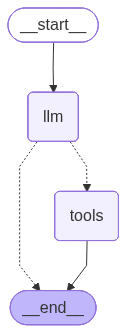

In [ ]:

from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage
from IPython.display import Image
## tool definiton
#----------------------

def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llmg.bind_tools([multiply])


def call_llm(state: MessagesState):
    print("--- Calling LLM ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}



builder = StateGraph(MessagesState)
builder.add_node("llm", call_llm)
builder.add_node(
    "tools",
    ToolNode([multiply])
)

builder.add_edge(START, "llm")
builder.add_conditional_edges(
    "llm",
    tools_condition
)
builder.add_edge("tools", END)
graph = builder.compile()


# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [9]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

--- Calling LLM ---
================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (509f045a-a8c7-4afe-ace4-b8f6e5351f33)
 Call ID: 509f045a-a8c7-4afe-ace4-b8f6e5351f33
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4


In [10]:
messages

{'messages': [HumanMessage(content='Hello, what is 2 multiplied by 2?', additional_kwargs={}, response_metadata={}, id='8f10d33a-5cca-4362-a686-8ddea812be51'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 2}'}, '__gemini_function_call_thought_signatures__': {'509f045a-a8c7-4afe-ace4-b8f6e5351f33': 'CsACAQw51sffDh0d0tXE3jgIda87TLRNIzqGWtGg9BafGJ2z1w4LA0Tsjv7Eu88JPyqwit0huHFlA6HKKf71bZdyhmB0dUgDM2FIu9Htq9wlh/ZXvyKcE2pQEi60nLOXbFNlIqy25cLIASp+pRAqSJYeXNTSzDZ+51emfltKrPphh/WJMeBcaT39YguaK5V2UCytA+Xghgc03ieNzvsUt+qnQWoBP84MQc6bN8fUHJVZ0G46ZIFvQToGCnxt6JeemIY/UcVwTyMveuPyBjkGJnqW3xz/4SaRfGhb40NWfpQqQmA3IEioD0jVacCKUfmVfMqRwT/JCW8KPwMtsnuh/WZ7puwlbRfoiGLZyjp6Af09qHcnIaefZu2wZNW3VbRocH0B/JpCKzPKFPqGn9EV/MphYUxf6htISnq79dISSqoc7gk='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f0275-a743-7411-a91e-7b4802c3b868-0', tool_calls=

## graph agent with tool

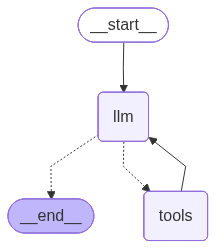

In [11]:

from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage
from IPython.display import Image
## tool definiton
#----------------------

def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llmg.bind_tools([multiply])


def call_llm(state: MessagesState):
    print("--- Calling LLM ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}



builder = StateGraph(MessagesState)
builder.add_node("llm", call_llm)
builder.add_node(
    "tools",
    ToolNode([multiply])
)

builder.add_edge(START, "llm")
builder.add_conditional_edges(
    "llm",
    tools_condition
)
builder.add_edge("tools", "llm")
graph = builder.compile()


# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

--- Calling LLM ---
--- Calling LLM ---
================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (289910c2-c1a9-4583-a296-f498a5cc2322)
 Call ID: 289910c2-c1a9-4583-a296-f498a5cc2322
  Args:
    b: 2
    a: 2
================================= Tool Message =================================
Name: multiply

4
================================== Ai Message ==================================

2 multiplied by 2 is 4.


## graph agent with custom tool node and conditional edge

In [15]:
from langgraph.graph import END
from langchain_core.messages import ToolMessage

def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llmg.bind_tools([multiply])


def call_llm(state: MessagesState):
    print("--- Calling LLM ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}



def my_tools_condition(state):
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return END


tool_map = {"multiply": multiply}

def custom_tool_node(state):
    print("--- Executing Tools ---")
    last_message = state["messages"][-1]
    tool_messages = []
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_func = tool_map[tool_name]
        result = tool_func(**tool_args)
        tool_messages.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            )
        )
    return {
        "messages": tool_messages
    }


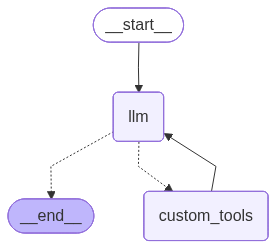

In [ ]:


builder = StateGraph(MessagesState)

builder.add_node("llm", call_llm)
builder.add_node("custom_tools", custom_tool_node)
builder.add_edge(START, "llm")
builder.add_conditional_edges(
    "llm",
    my_tools_condition,
    {
        "custom_tools": "custom_tools",
        END: END
    }
)

builder.add_edge("custom_tools", "llm")

graph = builder.compile()
# View
display(Image(graph.get_graph().draw_mermaid_png()))

### inside custom tool function execution

In [25]:
state = {'messages': [HumanMessage(content='Hello, what is 2 multiplied by 2?', additional_kwargs={}, response_metadata={}, id='8f10d33a-5cca-4362-a686-8ddea812be51'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 2}'}, '__gemini_function_call_thought_signatures__': {'509f045a-a8c7-4afe-ace4-b8f6e5351f33': 'CsACAQw51sffDh0d0tXE3jgIda87TLRNIzqGWtGg9BafGJ2z1w4LA0Tsjv7Eu88JPyqwit0huHFlA6HKKf71bZdyhmB0dUgDM2FIu9Htq9wlh/ZXvyKcE2pQEi60nLOXbFNlIqy25cLIASp+pRAqSJYeXNTSzDZ+51emfltKrPphh/WJMeBcaT39YguaK5V2UCytA+Xghgc03ieNzvsUt+qnQWoBP84MQc6bN8fUHJVZ0G46ZIFvQToGCnxt6JeemIY/UcVwTyMveuPyBjkGJnqW3xz/4SaRfGhb40NWfpQqQmA3IEioD0jVacCKUfmVfMqRwT/JCW8KPwMtsnuh/WZ7puwlbRfoiGLZyjp6Af09qHcnIaefZu2wZNW3VbRocH0B/JpCKzPKFPqGn9EV/MphYUxf6htISnq79dISSqoc7gk='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f0275-a743-7411-a91e-7b4802c3b868-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': '509f045a-a8c7-4afe-ace4-b8f6e5351f33', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 58, 'output_tokens': 84, 'total_tokens': 142, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 66}}),
  ToolMessage(content='4', name='multiply', id='0ead0a83-348c-47aa-8862-15119aa0ee11', tool_call_id='509f045a-a8c7-4afe-ace4-b8f6e5351f33')]}

In [29]:
state['messages'][-2]

AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 2}'}, '__gemini_function_call_thought_signatures__': {'509f045a-a8c7-4afe-ace4-b8f6e5351f33': 'CsACAQw51sffDh0d0tXE3jgIda87TLRNIzqGWtGg9BafGJ2z1w4LA0Tsjv7Eu88JPyqwit0huHFlA6HKKf71bZdyhmB0dUgDM2FIu9Htq9wlh/ZXvyKcE2pQEi60nLOXbFNlIqy25cLIASp+pRAqSJYeXNTSzDZ+51emfltKrPphh/WJMeBcaT39YguaK5V2UCytA+Xghgc03ieNzvsUt+qnQWoBP84MQc6bN8fUHJVZ0G46ZIFvQToGCnxt6JeemIY/UcVwTyMveuPyBjkGJnqW3xz/4SaRfGhb40NWfpQqQmA3IEioD0jVacCKUfmVfMqRwT/JCW8KPwMtsnuh/WZ7puwlbRfoiGLZyjp6Af09qHcnIaefZu2wZNW3VbRocH0B/JpCKzPKFPqGn9EV/MphYUxf6htISnq79dISSqoc7gk='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f0275-a743-7411-a91e-7b4802c3b868-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': '509f045a-a8c7-4afe-ace4-b8f6e5351f33', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input

In [ ]:
tool_map = {"multiply": multiply}

print("--- Executing Tools ---")
last_message = state["messages"][-2]
tool_messages = []
for tool_call in last_message.tool_calls:
    tool_name = tool_call["name"]
    tool_args = tool_call["args"]
    tool_func = tool_map[tool_name]
    result = tool_func(**tool_args)
    tool_messages.append(
        ToolMessage(
            content=str(result),
            tool_call_id=tool_call["id"]
        )
    )
rs = {
    "messages": tool_messages
}

--- Executing Tools ---


In [33]:
last_message

AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 2}'}, '__gemini_function_call_thought_signatures__': {'509f045a-a8c7-4afe-ace4-b8f6e5351f33': 'CsACAQw51sffDh0d0tXE3jgIda87TLRNIzqGWtGg9BafGJ2z1w4LA0Tsjv7Eu88JPyqwit0huHFlA6HKKf71bZdyhmB0dUgDM2FIu9Htq9wlh/ZXvyKcE2pQEi60nLOXbFNlIqy25cLIASp+pRAqSJYeXNTSzDZ+51emfltKrPphh/WJMeBcaT39YguaK5V2UCytA+Xghgc03ieNzvsUt+qnQWoBP84MQc6bN8fUHJVZ0G46ZIFvQToGCnxt6JeemIY/UcVwTyMveuPyBjkGJnqW3xz/4SaRfGhb40NWfpQqQmA3IEioD0jVacCKUfmVfMqRwT/JCW8KPwMtsnuh/WZ7puwlbRfoiGLZyjp6Af09qHcnIaefZu2wZNW3VbRocH0B/JpCKzPKFPqGn9EV/MphYUxf6htISnq79dISSqoc7gk='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f0275-a743-7411-a91e-7b4802c3b868-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': '509f045a-a8c7-4afe-ace4-b8f6e5351f33', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input

In [32]:
last_message.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 2},
  'id': '509f045a-a8c7-4afe-ace4-b8f6e5351f33',
  'type': 'tool_call'}]

In [35]:
tool_name = tool_call["name"]
tool_args = tool_call["args"]
tool_func = tool_map[tool_name]

In [36]:
tool_func

<function __main__.multiply(a: int, b: int) -> int>

In [37]:
tool_map

{'multiply': <function __main__.multiply(a: int, b: int) -> int>}

In [38]:
tool_messages

[ToolMessage(content='4', tool_call_id='509f045a-a8c7-4afe-ace4-b8f6e5351f33')]

## next

## graph based Agent with tool

## Persistance (checkpoint, thread id )

### stand tool agent with persistance

In [67]:

from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage
from IPython.display import Image
## tool definiton
#----------------------

def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])


def call_llm(state: MessagesState):
    print("--- Calling LLM ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}



builder = StateGraph(MessagesState)
builder.add_node("llm", call_llm)
builder.add_node(
    "tools",
    ToolNode([multiply])
)

builder.add_edge(START, "llm")
builder.add_conditional_edges(
    "llm",
    tools_condition
)
builder.add_edge("tools", "llm")


### persistance checkpoint

In [68]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer, store=store)

### response invoke

In [69]:
config = {"configurable": {"thread_id": "user-1"}}

messages = [HumanMessage(content="hello, my name is Bob")]
messages = graph.invoke({"messages": messages}, config = config)
messages

--- Calling LLM ---


{'messages': [HumanMessage(content='hello, my name is Bob', additional_kwargs={}, response_metadata={}, id='d94ebc82-c505-44cb-bc34-b0afc04c392b'),
  AIMessage(content="Hello Bob! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:17:54.014242056Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976591320, 'load_duration': None, 'prompt_eval_count': 296, 'prompt_eval_duration': None, 'eval_count': 37, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f029c-52e4-78c1-8f67-740976921f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 37, 'total_tokens': 333})]}

In [70]:
config = {"configurable": {"thread_id": "user-1"}}

messages = [HumanMessage(content="what is my name?")]
messages = graph.invoke({"messages": messages}, config = config)
messages

--- Calling LLM ---


{'messages': [HumanMessage(content='hello, my name is Bob', additional_kwargs={}, response_metadata={}, id='d94ebc82-c505-44cb-bc34-b0afc04c392b'),
  AIMessage(content="Hello Bob! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:17:54.014242056Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976591320, 'load_duration': None, 'prompt_eval_count': 296, 'prompt_eval_duration': None, 'eval_count': 37, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f029c-52e4-78c1-8f67-740976921f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 37, 'total_tokens': 333}),
  HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='c22e2dc0-067b-4e1a-9f1d-a3a6b13a0a63'),
  AIMessage(content='Your name is Bob, as you mentioned in your fir

### get_state() --> give current state snapshot after graph execution

In [72]:
latest = graph.get_state(config)

In [74]:
latest

StateSnapshot(values={'messages': [HumanMessage(content='hello, my name is Bob', additional_kwargs={}, response_metadata={}, id='d94ebc82-c505-44cb-bc34-b0afc04c392b'), AIMessage(content="Hello Bob! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:17:54.014242056Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976591320, 'load_duration': None, 'prompt_eval_count': 296, 'prompt_eval_duration': None, 'eval_count': 37, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f029c-52e4-78c1-8f67-740976921f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 37, 'total_tokens': 333}), HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='c22e2dc0-067b-4e1a-9f1d-a3a6b13a0a63'), AIMessage(content='Your name is Bob, as you mentio

In [76]:
snapshot = graph.get_state(config)

print("Values:")
print(snapshot.values)

print("\nNext:")
print(snapshot.next)

print("\nConfig:")
print(snapshot.config)

print("\nMetadata:")
print(snapshot.metadata)

print("\nCreated At:")
print(snapshot.created_at)

print("\nParent Config:")
print(snapshot.parent_config)

Values:
{'messages': [HumanMessage(content='hello, my name is Bob', additional_kwargs={}, response_metadata={}, id='d94ebc82-c505-44cb-bc34-b0afc04c392b'), AIMessage(content="Hello Bob! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:17:54.014242056Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976591320, 'load_duration': None, 'prompt_eval_count': 296, 'prompt_eval_duration': None, 'eval_count': 37, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f029c-52e4-78c1-8f67-740976921f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 37, 'total_tokens': 333}), HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='c22e2dc0-067b-4e1a-9f1d-a3a6b13a0a63'), AIMessage(content='Your name is Bob, as you mentioned in your f

In [77]:
config = {"configurable": {"thread_id": "user-2"}}

messages = [HumanMessage(content="hi I am manish")]
messages = graph.invoke({"messages": messages}, config = config)
messages

--- Calling LLM ---


{'messages': [HumanMessage(content='hi I am manish', additional_kwargs={}, response_metadata={}, id='d1526867-666d-4c40-bec7-5c23ee79cafc'),
  AIMessage(content='Hello Manish! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:24:20.651245382Z', 'done': True, 'done_reason': 'stop', 'total_duration': 948673425, 'load_duration': None, 'prompt_eval_count': 295, 'prompt_eval_duration': None, 'eval_count': 68, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02a2-391e-7d51-aaea-068144bca62c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 295, 'output_tokens': 68, 'total_tokens': 363})]}

In [82]:
config = {"configurable": {"thread_id": "user-2"}}
snapshot = graph.get_state(config)

print("Values:")
print(snapshot.values)

print("\nNext:")
print(snapshot.next)

print("\nConfig:")
print(snapshot.config)

print("\nMetadata:")
print(snapshot.metadata)

print("\nCreated At:")
print(snapshot.created_at)

print("\nParent Config:")
print(snapshot.parent_config)

Values:
{'messages': [HumanMessage(content='hi I am manish', additional_kwargs={}, response_metadata={}, id='d1526867-666d-4c40-bec7-5c23ee79cafc'), AIMessage(content='Hello Manish! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:24:20.651245382Z', 'done': True, 'done_reason': 'stop', 'total_duration': 948673425, 'load_duration': None, 'prompt_eval_count': 295, 'prompt_eval_duration': None, 'eval_count': 68, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02a2-391e-7d51-aaea-068144bca62c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 295, 'output_tokens': 68, 'total_tokens': 363})]}

Next:
()

Config:
{'configurable': {'thread_id': 'user-2', 'checkpoint_ns': '', 'checkpoint_id': '1f17128f-541f-612b-8001-285bec94bbae'}}

Metadata:
{'source': 'loop', 'step': 1, 'parents': {}}

Create

In [83]:
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='hi I am manish', additional_kwargs={}, response_metadata={}, id='d1526867-666d-4c40-bec7-5c23ee79cafc'), AIMessage(content='Hello Manish! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:24:20.651245382Z', 'done': True, 'done_reason': 'stop', 'total_duration': 948673425, 'load_duration': None, 'prompt_eval_count': 295, 'prompt_eval_duration': None, 'eval_count': 68, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02a2-391e-7d51-aaea-068144bca62c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 295, 'output_tokens': 68, 'total_tokens': 363})]}, next=(), config={'configurable': {'thread_id': 'user-2', 'checkpoint_ns': '', 'checkpoint_id': '1f17128f-541f-612b-8001-285bec94bbae'}}, metadata={'source': 'loop', 'step': 1, 'parents': {

### get_state_history() ---> gives list of all the snapshots of all previous states till present (p to s)

In [81]:
config = {"configurable": {"thread_id": "user-2"}}
list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='hi I am manish', additional_kwargs={}, response_metadata={}, id='d1526867-666d-4c40-bec7-5c23ee79cafc'), AIMessage(content='Hello Manish! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:24:20.651245382Z', 'done': True, 'done_reason': 'stop', 'total_duration': 948673425, 'load_duration': None, 'prompt_eval_count': 295, 'prompt_eval_duration': None, 'eval_count': 68, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02a2-391e-7d51-aaea-068144bca62c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 295, 'output_tokens': 68, 'total_tokens': 363})]}, next=(), config={'configurable': {'thread_id': 'user-2', 'checkpoint_ns': '', 'checkpoint_id': '1f17128f-541f-612b-8001-285bec94bbae'}}, metadata={'source': 'loop', 'step': 1, 'parents': 

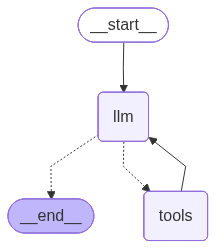

In [80]:
graph

In [84]:
# each node after executiopn contain some state value that is snapshot

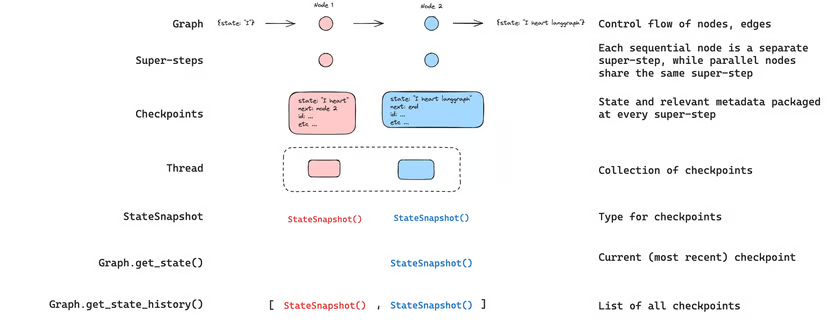

### filter the sate history to find specific state

In [85]:
history = list(graph.get_state_history(config))

# Find the checkpoint before a specific node executed
before_node_llm = next(s for s in history if s.next == ("llm",))

before_node_llm

StateSnapshot(values={'messages': [HumanMessage(content='hi I am manish', additional_kwargs={}, response_metadata={}, id='d1526867-666d-4c40-bec7-5c23ee79cafc')]}, next=('llm',), config={'configurable': {'thread_id': 'user-2', 'checkpoint_ns': '', 'checkpoint_id': '1f17128f-4545-62c6-8000-c76939c7f0c0'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-26T06:33:33.699347+00:00', parent_config={'configurable': {'thread_id': 'user-2', 'checkpoint_ns': '', 'checkpoint_id': '1f17128f-449b-6800-bfff-924fc1b4ff97'}}, tasks=(PregelTask(id='bd1e2326-7eae-1477-a10c-cf4b8b7ef9f3', name='llm', path=('__pregel_pull', 'llm'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='Hello Manish! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:24:20.651245382Z', 'done': True, 'done_reason': 'stop', 'total_duration': 948673425, 'load_duration': None, 

In [87]:
# Find a checkpoint by step number
step_2 = next(s for s in history if s.metadata["step"] == 1)

step_2

StateSnapshot(values={'messages': [HumanMessage(content='hi I am manish', additional_kwargs={}, response_metadata={}, id='d1526867-666d-4c40-bec7-5c23ee79cafc'), AIMessage(content='Hello Manish! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:24:20.651245382Z', 'done': True, 'done_reason': 'stop', 'total_duration': 948673425, 'load_duration': None, 'prompt_eval_count': 295, 'prompt_eval_duration': None, 'eval_count': 68, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02a2-391e-7d51-aaea-068144bca62c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 295, 'output_tokens': 68, 'total_tokens': 363})]}, next=(), config={'configurable': {'thread_id': 'user-2', 'checkpoint_ns': '', 'checkpoint_id': '1f17128f-541f-612b-8001-285bec94bbae'}}, metadata={'source': 'loop', 'step': 1, 'parents': {

### reexecute

In [89]:
config = {"configurable": {"thread_id": "user-1"}}
list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='hello, my name is Bob', additional_kwargs={}, response_metadata={}, id='d94ebc82-c505-44cb-bc34-b0afc04c392b'), AIMessage(content="Hello Bob! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:17:54.014242056Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976591320, 'load_duration': None, 'prompt_eval_count': 296, 'prompt_eval_duration': None, 'eval_count': 37, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f029c-52e4-78c1-8f67-740976921f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 37, 'total_tokens': 333}), HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='c22e2dc0-067b-4e1a-9f1d-a3a6b13a0a63'), AIMessage(content='Your name is Bob, as you menti

In [99]:
list(graph.get_state_history(config))[2].config

{'configurable': {'thread_id': 'user-1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f171280-eee6-6073-8002-a3de4069a245'}}

In [100]:
list(graph.get_state_history(config))[2].metadata

{'source': 'input', 'step': 2, 'parents': {}}

In [104]:
list(graph.get_state_history(config))[2].config

{'configurable': {'thread_id': 'user-1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f171280-eee6-6073-8002-a3de4069a245'}}

In [106]:
replay_config = {
    "configurable": {
        "thread_id": "thread-1",
        "checkpoint_id": '1f171280-eee6-6073-8002-a3de4069a245'
    }
}

result = graph.invoke(None, config=config)

In [107]:
result

{'messages': [HumanMessage(content='hello, my name is Bob', additional_kwargs={}, response_metadata={}, id='d94ebc82-c505-44cb-bc34-b0afc04c392b'),
  AIMessage(content="Hello Bob! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:17:54.014242056Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976591320, 'load_duration': None, 'prompt_eval_count': 296, 'prompt_eval_duration': None, 'eval_count': 37, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f029c-52e4-78c1-8f67-740976921f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 37, 'total_tokens': 333}),
  HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='c22e2dc0-067b-4e1a-9f1d-a3a6b13a0a63'),
  AIMessage(content='Your name is Bob, as you mentioned in your fir

In [110]:
result['messages'][-1].content

'Your name is Bob, as you mentioned in your first message.'

In [112]:
replay_config = {
    "configurable": {
        "thread_id": "thread-1",
        "checkpoint_id": '1f171280-eee6-6073-8002-a3de4069a245'
    }
}



In [113]:
for snapshot in graph.get_state_history(config):

    checkpoint_id = snapshot.config["configurable"]["checkpoint_id"]

    print("=" * 80)
    print("Checkpoint:", checkpoint_id)
    print("State:", snapshot.values)

Checkpoint: 1f171281-096c-671e-8004-d77e56ee5305
State: {'messages': [HumanMessage(content='hello, my name is Bob', additional_kwargs={}, response_metadata={}, id='d94ebc82-c505-44cb-bc34-b0afc04c392b'), AIMessage(content="Hello Bob! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:17:54.014242056Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976591320, 'load_duration': None, 'prompt_eval_count': 296, 'prompt_eval_duration': None, 'eval_count': 37, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f029c-52e4-78c1-8f67-740976921f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 37, 'total_tokens': 333}), HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='c22e2dc0-067b-4e1a-9f1d-a3a6b13a0a63'), AIMessage(conte

### update state

In [118]:
list(graph.get_state_history(config))[1].values

{'messages': [HumanMessage(content='hello, my name is Bob', additional_kwargs={}, response_metadata={}, id='d94ebc82-c505-44cb-bc34-b0afc04c392b'),
  AIMessage(content="Hello Bob! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:17:54.014242056Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976591320, 'load_duration': None, 'prompt_eval_count': 296, 'prompt_eval_duration': None, 'eval_count': 37, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f029c-52e4-78c1-8f67-740976921f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 37, 'total_tokens': 333}),
  HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='c22e2dc0-067b-4e1a-9f1d-a3a6b13a0a63')]}

In [119]:
list(graph.get_state_history(config))[1].config

{'configurable': {'thread_id': 'user-1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f171280-f019-6920-8003-2c7e28dbab31'}}

In [123]:
from langchain_core.messages import AIMessage, HumanMessage

# 1. Your existing thread configuration
config = {"configurable": {"thread_id": "user-1"}}

# 2. Define the new message you want to append to the state
# For example, correcting the AI's mistake or manually adding the next turn
new_updates = {
    "messages": [
         HumanMessage(content='what is my contry name?')
    ]
}

# 3. Update the state
# This creates a new checkpoint inheriting the history and appending the new message
updated_config = graph.update_state(config, values=new_updates)


In [124]:
updated_config

{'configurable': {'thread_id': 'user-1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1712d9-cb3a-62ed-8005-52308ada69e7'}}

In [125]:
list(graph.get_state_history(config))[1].values

{'messages': [HumanMessage(content='hello, my name is Bob', additional_kwargs={}, response_metadata={}, id='d94ebc82-c505-44cb-bc34-b0afc04c392b'),
  AIMessage(content="Hello Bob! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T06:17:54.014242056Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976591320, 'load_duration': None, 'prompt_eval_count': 296, 'prompt_eval_duration': None, 'eval_count': 37, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f029c-52e4-78c1-8f67-740976921f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 37, 'total_tokens': 333}),
  HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='c22e2dc0-067b-4e1a-9f1d-a3a6b13a0a63'),
  AIMessage(content='Your name is Bob, as you mentioned in your fir

## next

## event steaming

### stand tool agent

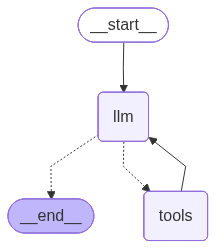

In [162]:

from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage
from IPython.display import Image
## tool definiton
#----------------------

def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])


def call_llm(state: MessagesState):
    print("--- Calling LLM ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}



builder = StateGraph(MessagesState)
builder.add_node("llm", call_llm)
builder.add_node(
    "tools",
    ToolNode([multiply])
)

builder.add_edge(START, "llm")
builder.add_conditional_edges(
    "llm",
    tools_condition
)
builder.add_edge("tools", "llm")


from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

### invoke()

In [163]:
config = {"configurable": {"thread_id": "user-1"}}

messages = [HumanMessage(content="how much 2 multiply by 2?")]
messages = graph.invoke({"messages": messages}, config = config)
messages

--- Calling LLM ---
--- Calling LLM ---


{'messages': [HumanMessage(content='how much 2 multiply by 2?', additional_kwargs={}, response_metadata={}, id='842349e6-e79c-47c4-88f7-8fa40f996a90'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T07:24:56.434275016Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2786522176, 'load_duration': None, 'prompt_eval_count': 299, 'prompt_eval_duration': None, 'eval_count': 98, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02d9-ac50-7af1-ac06-1a5ef014f333-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'fa0dda6d-f7ab-4baa-b2a1-25b3a5ddcaae', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 299, 'output_tokens': 98, 'total_tokens': 397}),
  ToolMessage(content='4', name='multiply', id='61976480-5853-4300-a7c7-52f74e17c830', tool_call_id='fa0dda6d-f7ab-4baa-b2a1-25b3a5ddcaae'),


In [166]:
messages['messages'][-1].content

'2 multiplied by 2 equals 4.'

### stream_event() / stream() / astream()

| API                     | Returns                              |
| ----------------------- | ------------------------------------ |
| `graph.invoke()`        | Final result only                    |
| `graph.stream()`        | State updates                        |
| `graph.astream()`       | Async state updates                  |
| `graph.stream_events()` | Tokens + messages + state + metadata |


So invoke() is essentially "give me the final state", while stream() is "show me what happens during execution and eventually give me the final state too."


invoke()

    Order food
    (wait)
    (wait)
    (wait)
    Food arrives

stream()

    Order received
    Chef started cooking
    Food ready
    Out for delivery
    Delivered

### stream_event() its new api

In [167]:
config = {"configurable": {"thread_id": "user-2"}}
stream = graph.stream_events(
    {
        "messages": [
            {
                "role": "user",
                "content": "how much 2 multiply by 2?"
            }
        ]
    }, config = config,
    version="v3"
)

In [168]:
stream

In [169]:
for message in stream.messages:
    for token in message.text:
        print(token, end="", flush=True)

--- Calling LLM ---
--- Calling LLM ---
2 multiplied by 2 equals 4.

In [170]:
graph.get_state(config).values

{'messages': [HumanMessage(content='how much 2 multiply by 2?', additional_kwargs={}, response_metadata={}, id='f000f700-5913-4597-99e6-66f7faecd1d0'),
  AIMessage(content=[{'type': 'tool_call', 'id': 'ebfa6ebb-f96a-49d5-9997-2108d924732c', 'name': 'multiply', 'args': {'a': 2, 'b': 2}}], additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T07:26:29.322810759Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976496968, 'load_duration': None, 'prompt_eval_count': 299, 'prompt_eval_duration': None, 'eval_count': 75, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama', 'output_version': 'v1'}, id='lc_run--019f02db-1e1f-70e2-abd1-2cfc3eae61b2', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'ebfa6ebb-f96a-49d5-9997-2108d924732c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 299, 'output_tokens': 75, 'total_tokens': 374}),
  ToolM

In [ ]:
### final output

In [171]:
final_state = stream.output

print(final_state)

{'messages': [HumanMessage(content='how much 2 multiply by 2?', additional_kwargs={}, response_metadata={}, id='f000f700-5913-4597-99e6-66f7faecd1d0'), AIMessage(content=[{'type': 'tool_call', 'id': 'ebfa6ebb-f96a-49d5-9997-2108d924732c', 'name': 'multiply', 'args': {'a': 2, 'b': 2}}], additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T07:26:29.322810759Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976496968, 'load_duration': None, 'prompt_eval_count': 299, 'prompt_eval_duration': None, 'eval_count': 75, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama', 'output_version': 'v1'}, id='lc_run--019f02db-1e1f-70e2-abd1-2cfc3eae61b2', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'ebfa6ebb-f96a-49d5-9997-2108d924732c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 299, 'output_tokens': 75, 'total_tokens': 374}), ToolMessa

In [ ]:
final_state

{'messages': [HumanMessage(content='how much 2 multiply by 2?', additional_kwargs={}, response_metadata={}, id='f000f700-5913-4597-99e6-66f7faecd1d0'),
  AIMessage(content=[{'type': 'tool_call', 'id': 'ebfa6ebb-f96a-49d5-9997-2108d924732c', 'name': 'multiply', 'args': {'a': 2, 'b': 2}}], additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T07:26:29.322810759Z', 'done': True, 'done_reason': 'stop', 'total_duration': 976496968, 'load_duration': None, 'prompt_eval_count': 299, 'prompt_eval_duration': None, 'eval_count': 75, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama', 'output_version': 'v1'}, id='lc_run--019f02db-1e1f-70e2-abd1-2cfc3eae61b2', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'ebfa6ebb-f96a-49d5-9997-2108d924732c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 299, 'output_tokens': 75, 'total_tokens': 374}),
  ToolM

In [183]:
final_state['messages'][-1].content[0]['text']

'2 multiplied by 2 equals 4.'

#### concept 2

In [185]:
config = {"configurable": {"thread_id": "user-3"}}
stream = graph.stream_events(
    {
        "messages": [
            {
                "role": "user",
                "content": "how much 7 multiply by 2?"
            }
        ]
    }, config = config,
    version="v3"
)

In [186]:
for event in stream:
    print(event)

{'type': 'event', 'method': 'values', 'params': {'namespace': [], 'timestamp': 1782460094132, 'data': {'messages': [HumanMessage(content='how much 7 multiply by 2?', additional_kwargs={}, response_metadata={}, id='c073213f-ec28-4857-9c3d-b08ae13e2dce')]}, 'interrupts': ()}, 'seq': 1}
--- Calling LLM ---
{'type': 'event', 'method': 'messages', 'params': {'namespace': [], 'timestamp': 1782460095815, 'data': ({'event': 'message-start', 'role': 'ai', 'id': 'lc_run--019f02e6-9990-7082-bc72-33bed15ca54f'}, {'thread_id': 'user-3', 'ls_integration': 'langchain_chat_model', 'langgraph_step': 1, 'langgraph_node': 'llm', 'langgraph_triggers': ('branch:to:llm',), 'langgraph_path': ('__pregel_pull', 'llm'), 'langgraph_checkpoint_ns': 'llm:50f97ecd-8351-e0f8-dc6e-65e22d128502', 'checkpoint_ns': 'llm:50f97ecd-8351-e0f8-dc6e-65e22d128502', 'ls_provider': 'ollama', 'ls_model_name': 'nemotron-3-super:cloud', 'ls_model_type': 'chat', 'ls_temperature': None, 'run_id': '019f02e6-9990-7082-bc72-33bed15ca54f

In [188]:
stream.output

{'messages': [HumanMessage(content='how much 7 multiply by 2?', additional_kwargs={}, response_metadata={}, id='c073213f-ec28-4857-9c3d-b08ae13e2dce'),
  AIMessage(content=[{'type': 'tool_call', 'id': '5ef80a83-c1de-4d8a-997f-7967e82698ff', 'name': 'multiply', 'args': {'a': 7, 'b': 2}}], additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T07:39:01.766762255Z', 'done': True, 'done_reason': 'stop', 'total_duration': 882895330, 'load_duration': None, 'prompt_eval_count': 299, 'prompt_eval_duration': None, 'eval_count': 85, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama', 'output_version': 'v1'}, id='lc_run--019f02e6-9990-7082-bc72-33bed15ca54f', tool_calls=[{'name': 'multiply', 'args': {'a': 7, 'b': 2}, 'id': '5ef80a83-c1de-4d8a-997f-7967e82698ff', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 299, 'output_tokens': 85, 'total_tokens': 384}),
  ToolM

### stream() ---with update

In [189]:
config = {"configurable": {"thread_id": "user-4"}}

for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "how much 2 multiply by 2?"
            }
        ]
    },
    config=config,
    stream_mode="updates"
):
    print(chunk)

--- Calling LLM ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T07:45:21.572780394Z', 'done': True, 'done_reason': 'stop', 'total_duration': 884978271, 'load_duration': None, 'prompt_eval_count': 299, 'prompt_eval_duration': None, 'eval_count': 96, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02ec-6598-7643-b72f-ad1d4d4d82e3-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'effb8a1a-45bb-4950-9067-52845e61c2b2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 299, 'output_tokens': 96, 'total_tokens': 395})]}}
{'tools': {'messages': [ToolMessage(content='4', name='multiply', id='6d09ad28-389e-4a3d-a95a-35cf521021af', tool_call_id='effb8a1a-45bb-4950-9067-52845e61c2b2')]}}
--- Calling LLM ---
{'llm': {'messages': [AIMessage(content='2\u202f×\u202f2\u202f=\u20

In [191]:
chunk

{'llm': {'messages': [AIMessage(content='2\u202f×\u202f2\u202f=\u202f4.', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T07:45:23.314083015Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1046904896, 'load_duration': None, 'prompt_eval_count': 350, 'prompt_eval_duration': None, 'eval_count': 33, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02ec-6c12-7aa0-9f95-80555ba39e9c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 350, 'output_tokens': 33, 'total_tokens': 383})]}}

In [206]:
print(f['llm']['messages'][0].content)

2 × 2 = 4.


### stream() --> by values

In [192]:
config = {"configurable": {"thread_id": "user-4"}}

for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "how much 4 multiply by 2?"
            }
        ]
    },
    config=config,
    stream_mode="values"
):
    print(chunk)

{'messages': [HumanMessage(content='how much 2 multiply by 2?', additional_kwargs={}, response_metadata={}, id='e192e06a-60cd-4981-9f66-0e9ccf5c20f5'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T07:45:21.572780394Z', 'done': True, 'done_reason': 'stop', 'total_duration': 884978271, 'load_duration': None, 'prompt_eval_count': 299, 'prompt_eval_duration': None, 'eval_count': 96, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02ec-6598-7643-b72f-ad1d4d4d82e3-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'effb8a1a-45bb-4950-9067-52845e61c2b2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 299, 'output_tokens': 96, 'total_tokens': 395}), ToolMessage(content='4', name='multiply', id='6d09ad28-389e-4a3d-a95a-35cf521021af', tool_call_id='effb8a1a-45bb-4950-9067-52845e61c2b2'), AIMes

In [193]:
chunk

{'messages': [HumanMessage(content='how much 2 multiply by 2?', additional_kwargs={}, response_metadata={}, id='e192e06a-60cd-4981-9f66-0e9ccf5c20f5'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T07:45:21.572780394Z', 'done': True, 'done_reason': 'stop', 'total_duration': 884978271, 'load_duration': None, 'prompt_eval_count': 299, 'prompt_eval_duration': None, 'eval_count': 96, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02ec-6598-7643-b72f-ad1d4d4d82e3-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'effb8a1a-45bb-4950-9067-52845e61c2b2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 299, 'output_tokens': 96, 'total_tokens': 395}),
  ToolMessage(content='4', name='multiply', id='6d09ad28-389e-4a3d-a95a-35cf521021af', tool_call_id='effb8a1a-45bb-4950-9067-52845e61c2b2'),
 

In [197]:
print(chunk['messages'][-1].content)

4 × 2 = 8.


### astream()

In [140]:
from langchain_core.messages import HumanMessage

async def run_graph():

    config = {
        "configurable": {
            "thread_id": "user-1"
        }
    }

    inputs = {
        "messages": [
            HumanMessage(
                content="how much is 2 multiplied by 2?"
            )
        ]
    }

    async for chunk in graph.astream(
        inputs,
        config=config,
        stream_mode="updates"
    ):
        print(chunk)

await run_graph()

--- Calling LLM ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-26T07:13:28.536985142Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1219990752, 'load_duration': None, 'prompt_eval_count': 300, 'prompt_eval_duration': None, 'eval_count': 100, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019f02cf-335d-77f0-9dae-4a731cdf1d1c-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': '5d179fcb-539b-4575-9f0a-fb1699e9be49', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 300, 'output_tokens': 100, 'total_tokens': 400})]}}
{'tools': {'messages': [ToolMessage(content='4', name='multiply', id='5999c948-1823-48de-923d-de2c11acb704', tool_call_id='5d179fcb-539b-4575-9f0a-fb1699e9be49')]}}
--- Calling LLM ---
{'llm': {'messages': [AIMessage(content='2 multiplied by 2 equal

## Intrrupt

### sample graph

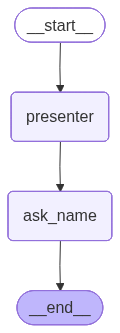

In [250]:
from typing import TypedDict
from langgraph.types import interrupt

class State(TypedDict):
    name : str
    tag: str

def presenter(state):
    return {"tag" : state['tag']}

def ask_name(state):
    name = interrupt("what is your name?")
    return {"name" : name + "Musk"}

checkpointer = InMemorySaver()
builder = StateGraph(State)

builder.add_node("presenter" , presenter)
builder.add_node("ask_name", ask_name)
builder.add_edge(START, 'presenter')
builder.add_edge('presenter', "ask_name")
builder.add_edge("ask_name", END)

graph = builder.compile(checkpointer= checkpointer)
graph

In [251]:
config = {"configurable": {"thread_id" : "user-1"}}

result = graph.invoke({'tag' : "Bot predict you sir name"}, config=config)

In [252]:
result

{'tag': 'Bot predict you sir name',
 '__interrupt__': [Interrupt(value='what is your name?', id='b872572d056917786fba8e7acb35b20a')]}

In [253]:
result.keys()

dict_keys(['tag', '__interrupt__'])

In [232]:
(list(graph.get_state(config)))

[{'tag': 'Bot predict you sir name'},
 ('ask_name',),
 {'configurable': {'thread_id': 'user-1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f171391-3ad0-63dd-8001-4661f31675cc'}},
 {'source': 'loop', 'step': 1, 'parents': {}},
 '2026-06-26T08:28:58.237641+00:00',
 {'configurable': {'thread_id': 'user-1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f171391-32ba-6ab7-8000-d620805f8c89'}},
 (PregelTask(id='51247a5d-ad63-62ba-1738-842371257762', name='ask_name', path=('__pregel_pull', 'ask_name'), error=None, interrupts=(Interrupt(value='what is your name?', id='475dc2110308aa935ae1c0756e7fb046'),), state=None, result=None),),
 (Interrupt(value='what is your name?', id='475dc2110308aa935ae1c0756e7fb046'),)]

In [254]:
(list(graph.get_state_history(config)))

[StateSnapshot(values={'tag': 'Bot predict you sir name'}, next=('ask_name',), config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17139d-a74c-6320-8001-1c4f0b36598f'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-26T08:34:31.735580+00:00', parent_config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17139d-a71c-6813-8000-b1fe09f29426'}}, tasks=(PregelTask(id='4cb091f4-668a-f4cf-ae1e-7924befabc69', name='ask_name', path=('__pregel_pull', 'ask_name'), error=None, interrupts=(Interrupt(value='what is your name?', id='b872572d056917786fba8e7acb35b20a'),), state=None, result=None),), interrupts=(Interrupt(value='what is your name?', id='b872572d056917786fba8e7acb35b20a'),)),
 StateSnapshot(values={'tag': 'Bot predict you sir name'}, next=('presenter',), config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17139d-a71c-6813-8000-b1fe09f29426'}}, metadata=

In [255]:
result['__interrupt__'][0].value

'what is your name?'

In [256]:
from langgraph.types import Command

graph.invoke(Command(resume="Kunnu"),config=config)

{'name': 'KunnuMusk', 'tag': 'Bot predict you sir name'}

In [257]:
(list(graph.get_state(config)))

[{'name': 'KunnuMusk', 'tag': 'Bot predict you sir name'},
 (),
 {'configurable': {'thread_id': 'user-1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f17139f-9e59-6bef-8002-e0a77fdde86a'}},
 {'source': 'loop', 'step': 2, 'parents': {}},
 '2026-06-26T08:35:24.484503+00:00',
 {'configurable': {'thread_id': 'user-1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f17139d-a74c-6320-8001-1c4f0b36598f'}},
 (),
 ()]

In [258]:
(list(graph.get_state_history(config)))

[StateSnapshot(values={'name': 'KunnuMusk', 'tag': 'Bot predict you sir name'}, next=(), config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17139f-9e59-6bef-8002-e0a77fdde86a'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-26T08:35:24.484503+00:00', parent_config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17139d-a74c-6320-8001-1c4f0b36598f'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'tag': 'Bot predict you sir name'}, next=('ask_name',), config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17139d-a74c-6320-8001-1c4f0b36598f'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-26T08:34:31.735580+00:00', parent_config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17139d-a71c-6813-8000-b1fe09f29426'}}, tasks=(PregelTask(id='4cb091f4-668a-f4cf-ae1e-7924befabc69', name='ask_name'

### concept3

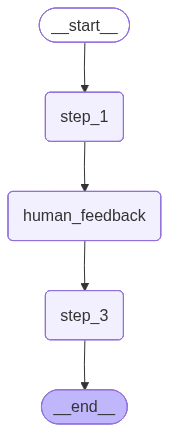

In [263]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    input: str
    user_feedback: str

def step_1(state):
    print("---Step 1---")
    pass

def human_feedback(state):
    print("---human_feedback---")
    feedback = interrupt("Please provide feedback:")
    return {"user_feedback": feedback}

def step_3(state):
    print("---Step 3---")
    pass

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("human_feedback", human_feedback)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "human_feedback")
builder.add_edge("human_feedback", "step_3")
builder.add_edge("step_3", END)

# Set up memory
memory = InMemorySaver()

# Add
graph = builder.compile(checkpointer=memory)
graph

In [261]:
# Input
initial_input = {"input": "hello world"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

---Step 1---
{'step_1': None}


---human_feedback---
{'__interrupt__': (Interrupt(value='Please provide feedback:', id='4108b6fadeb91c40ebdcd607f794ff59'),)}




In [264]:
# Input
initial_input = {"input": "hello world"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    print(event)
    print("\n")

{'input': 'hello world'}


---Step 1---
---human_feedback---
{'input': 'hello world', '__interrupt__': (Interrupt(value='Please provide feedback:', id='9f1ddb67ad0d0f97a3396a186a5870ae'),)}




In [265]:
# Continue the graph execution
for event in graph.stream(
    Command(resume="go to step 3!"),
    thread,
    stream_mode="updates",
):
    print(event)
    print("\n")

---human_feedback---
{'human_feedback': {'user_feedback': 'go to step 3!'}}


---Step 3---
{'step_3': None}




In [266]:
# Continue the graph execution
for event in graph.stream(
    Command(resume="go to step 3!"),
    thread,
    stream_mode="values",
):
    print(event)
    print("\n")

{'input': 'hello world', 'user_feedback': 'go to step 3!'}


